# 03 · What does a model take and give back?

## Overview

A model is a file of numbers. It takes numbers in and gives numbers back. It never sees your
photo directly: VisionServe first changes the photo into the numbers the model expects. In this
notebook you look at both sides: what goes in, and what comes out.

**What you will learn**

- How to read a model card with `visionserve inspect` (files, size, inputs, outputs).
- What a shape such as `[1, 3, 560, 560]` means, in plain words.
- How to see the exact picture the model gets from your photo.
- How to inspect a bare `.onnx` file that has no manifest.
- What a broken manifest looks like, and how to read the `FAIL` message.
- How to get the real input numbers from the server with `client.preprocess()`.
- How a box found by the model is moved back onto your photo.
- Four ways to fit a photo into a model's square: squash, letterbox, centre crop, long side.

**Time:** about 25 minutes.

**Before you start**

- A running VisionServe server (see notebook 00 and the setup in `README.md`). By default the notebook talks to
  `http://127.0.0.1:11435`; set the environment variable `VS_HOST` for another address.
- The `visionserve` command-line program (the Go binary), setup step 3 in `README.md`.
- The models `rf-detr`, `efficientnet-b0` and `mobile-sam`. The notebook downloads a missing
  model for you (`visionserve pull`).
- No GPU is needed. `inspect` loads nothing, and the other steps are small.

**Steps**

1. Set up
2. Read the model card
3. The input shape in plain words
4. See what the model really gets
5. A bare `.onnx` file
6. A broken manifest
7. The real input numbers: `client.preprocess()`
8. From the model's square back to your photo
9. Four ways to fit a photo into a square
10. Clean up

## 1. Set up

We import the helper file `handson.py` (it is in this folder), connect to the server, and make
sure the three models we use are installed. We also make a scratch folder, `work-03`, for the
files we create. We delete it at the end.

In [1]:
import json
import re
import shutil
import difflib
from pathlib import Path

import numpy as np
from PIL import Image, ImageDraw

import handson as ho

client = ho.connect()
for name in ["rf-detr", "efficientnet-b0", "mobile-sam"]:
    ho.ensure_model(client, name)

WORK = Path("work-03")      # scratch folder for this notebook
WORK.mkdir(exist_ok=True)


def cli_json(*args):
    """Run a visionserve command with --json and return the JSON object it prints."""
    out = ho.run_cli(*args, "--json", echo=False)
    return json.loads(out[out.index("{"): out.rindex("}") + 1])

Connected to VisionServe at http://127.0.0.1:11785: {'status': 'ok'}
Model 'rf-detr' is installed (state: available).
Model 'efficientnet-b0' is installed (state: available).
Model 'mobile-sam' is installed (state: available).


**What you see**

One line from the server (`Connected to VisionServe ...`) and one line per model
(`installed`). If a model was missing, you also see the download.

`cli_json` is a small function for later: it runs a command with `--json` and gives back a
Python dictionary instead of text.

<details><summary><b>In detail</b></summary>

- **Server**: the program that runs the models. Your code sends it a photo over HTTP and gets
  an answer back as JSON (a text format for data).
- **Client**: your side. Here it is `visionserve.Client`, the Python SDK (software development
  kit, a library to talk to the server).
- **Manifest**: a small text file, `manifest.yaml`, next to each model file. It says what the
  model does, its licence, its input size, and how to prepare a photo for it.
- **Registry**: the folder that holds all installed models, one sub-folder per model. The default
  is `~/.visionserve/models`; the environment variable `VISIONSERVE_MODELS` changes it.

More: [Getting started](https://mtbui2010.github.io/visionserve/getting-started/) and [What the models do](https://mtbui2010.github.io/visionserve/concepts/tasks/).

</details>

## 2. Read the model card

`visionserve inspect NAME` prints a **model card**: a short report about one installed model.
It reads the files only. It does not run the model, and it does not need the server.

In [2]:
card = ho.run_cli("inspect", "rf-detr")

$ visionserve inspect rf-detr


PASS: rf-detr is ready to serve: its preprocessing makes a [1,3,560,560] tensor and rf-detr-base-real.onnx accepts it


  Model           rf-detr


  Task            detection


  Architecture    rf-detr


...

Next steps


  visionserve run rf-detr photo.jpg   # predict, JSON on stdout (--save draws the result)


  visionserve inspect rf-detr --image photo.jpg   # see the exact tensor the model gets


  edit ~/.visionserve/models/rf-detr/manifest.yaml   # format: docs/manifest-spec.md


(exit code 0)


**What you see**

The **first line** is the answer: `PASS` means "this model can be served". It can also say
`WARN` (it works, but look at something) or `FAIL` (it will not work).

Then the summary, line by line:

| Line | In plain words |
|---|---|
| `Task` | What the model does. `detection` = it finds objects and gives a box and a class name for each. |
| `Licence` | Only Apache-2.0, MIT and BSD are allowed. These licences let anyone use the model, also in a product. |
| `Files` | One ONNX file of about 103 MiB. **ONNX** is a standard file format for trained models. |
| `Parameters` | About 26.9 million. A **parameter** is one learned number inside the model. More parameters usually means slower but more accurate. |
| `Input` | How your photo is prepared: squashed to 560 × 560, colours scaled with the ImageNet mean and std, then turned into a **tensor** (a block of numbers) of shape `[1,3,560,560]`. |
| `Fits the graph` | `yes`: the prepared tensor has exactly the shape the model file accepts. The **graph** is the list of calculations inside the ONNX file. |
| `Outputs` | `pred_boxes [1,300,4]`: 300 candidate boxes with 4 numbers each. `pred_logits [1,300,91]`: 91 class scores for each candidate. |
| `Runs on` | The hardware it will try, in order: `cuda` (an NVIDIA GPU), else `cpu`. |

Below the summary come the details: each file with its SHA-256 check (a fingerprint of the
file), each ONNX input and output, the preparation step by step, and the runtime settings.

<details><summary><b>In detail</b></summary>

- **The 300 candidates.** RF-DETR always returns 300 candidate objects (called *object queries*).
  Most of them have a low score. The server keeps only the ones above the manifest's
  `conf_threshold` (0.5 for RF-DETR). RF-DETR needs no NMS (non-maximum suppression, the step that
  removes duplicate boxes in older detectors like YOLO): each query is already one object.
- **91 classes, not 80.** COCO, the data set RF-DETR was trained on, has 80 object types, but
  their ids go from 1 to 90 with gaps. The model keeps one slot per id, so the label file
  `coco91.txt` has 91 lines, with `N/A` in the gaps.
- **Exit status.** `inspect` exits with 0 for PASS or WARN, 1 for FAIL, 2 for a usage error, so a
  script can use it. `--json` prints one JSON object; `--report card.html` writes a page you can
  share.

More: [See what a model takes and returns](https://mtbui2010.github.io/visionserve/guides/see-a-model/) and
[Inspect and verify a model, section 1](https://mtbui2010.github.io/visionserve/guides/inspect/#1-inspect-the-model-file).

</details>

## 3. The input shape in plain words

The card says the model takes a tensor of shape `[1, 3, 560, 560]`. A **tensor** is a block of
numbers with several **axes** (directions), like a table that can have more than two
directions. The **shape** lists how long each axis is. Let us make an empty tensor of that shape
and count.

photos at once (batch)   1
colours (channels)       3
rows (height)            560
columns (width)          560
numbers in total: 940,800
memory: 3.8 MB  (each number is a 4-byte float32)


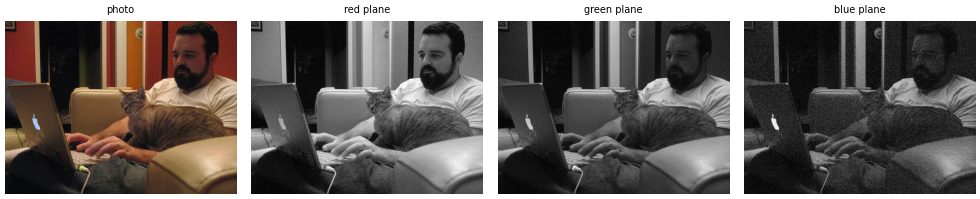

In [3]:
shape = (1, 3, 560, 560)
x = np.zeros(shape, dtype=np.float32)

for meaning, size in zip(["photos at once (batch)", "colours (channels)", "rows (height)", "columns (width)"], shape):
    print(f"{meaning:<24} {size}")
print("numbers in total:", f"{x.size:,}")
print("memory:", round(x.nbytes / 1e6, 1), "MB  (each number is a 4-byte float32)")

img = Image.open(ho.photo("cat")).convert("RGB")
r, g, b = img.split()
ho.show_side_by_side([img, r, g, b], titles=["photo", "red plane", "green plane", "blue plane"])

**What you see**

Read the shape from left to right:

- `1`: one photo at a time. This axis is called the **batch**.
- `3`: three colour planes: red, green, blue. These are the **channels**.
- `560`: 560 rows (the height).
- `560`: 560 columns (the width).

So the model gets 1 × 3 × 560 × 560 = 940,800 numbers, about 3.8 MB. The pictures show the
three planes of the cat photo. Each plane is a gray picture: bright where that colour is strong.
Look at the red wall: bright in the red plane, dark in the blue plane.
The model gets the three planes one after the other. This order (batch, channels, height, width)
is called **NCHW**.

<details><summary><b>In detail</b></summary>

- **float32** is a number with a decimal point, stored in 4 bytes. A photo stores each colour as
  a whole number from 0 to 255 (1 byte). The model wants decimal numbers near 0, so the server
  converts them: `value = (pixel / 255 - mean) / std` for each channel.
- Some models use another order: **NHWC** (height, width, channels). MobileSAM's encoder is one
  of them. The manifest says which (`layout`).
- The batch axis exists because a model can work on many photos at once. VisionServe sends one
  photo per request.

More: [From pixels to tensors, step 2](https://mtbui2010.github.io/visionserve/concepts/preprocessing/#step-2-turn-pixels-into-the-right-numbers).

</details>

## 4. See what the model really gets

`inspect --image PHOTO` runs the model's real preparation on your photo. It turns the tensor
back into a picture and saves it (`--image-out`). This is exactly what the model sees. We print
only the part of the output about the photo.

$ visionserve inspect rf-detr --image images/cat.jpg --image-out work-03/rf-detr-input.png


Input tensor for images/cat.jpg
  Photo    images/cat.jpg, 640×480
  Tensor   model/input [1,3,560,560] float32
  Values   min -2.118, max 2.64, mean per channel [-0.4806, -0.8674, -0.9193]
  Mapping  tensor_x = photo_x × 0.875 + 0, tensor_y = photo_y × 1.167 + 0 (how boxes map back)
  Picture  work-03/rf-detr-input.png (normalisation undone)
  [image: what the model sees: the tensor turned back into a picture (normalisation undone) — in the --report HTML]




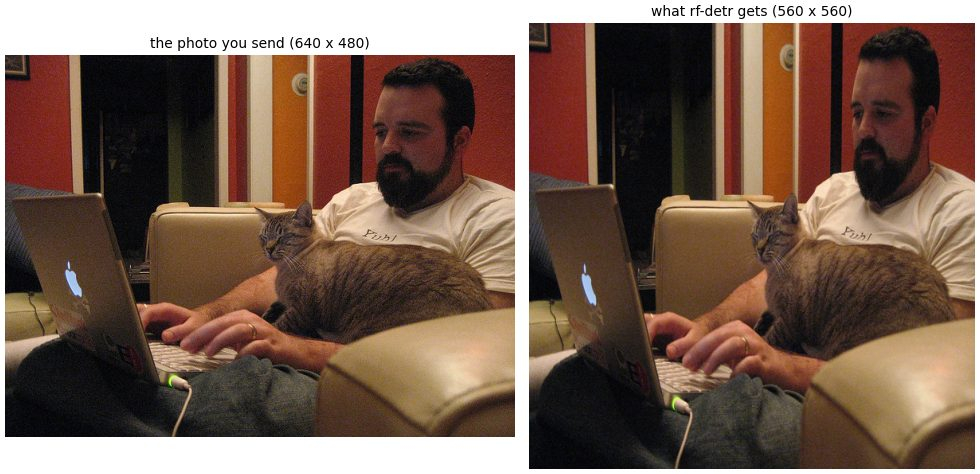

In [4]:
seen_png = WORK / "rf-detr-input.png"
print(f"$ visionserve inspect rf-detr --image {ho.photo('cat')} --image-out {seen_png}")
out = ho.run_cli("inspect", "rf-detr", "--image", ho.photo("cat"), "--image-out", seen_png, echo=False)
print(out[out.index("Input tensor for"):out.index("Next steps")])

ho.show_side_by_side([ho.photo("cat"), seen_png],
                     titles=["the photo you send (640 x 480)", "what rf-detr gets (560 x 560)"])

**What you see**

- `Tensor`: the shape `[1,3,560,560]` from the card, now for this photo.
- `Values`: the numbers go from about -2.1 to 2.6. This is after the colour scaling (mean and
  std), so they are no longer 0 to 255.
- `Mapping`: how a point of your photo moves into the model's square:
  `tensor_x = photo_x × 0.875` and `tensor_y = photo_y × 1.167`. The two numbers are different:
  the photo is **squashed** (stretched), the aspect ratio is not kept.
- The right picture: the whole photo, a little taller and thinner. The cat looks narrower. This
  is normal for RF-DETR, because it was trained on squashed photos too.

<details><summary><b>In detail</b></summary>

- The **aspect ratio** is width divided by height. The photo is 640 / 480 = 1.33; the square is
  1.0. To fill the square, the photo is stretched in height (× 1.167) and shrunk in width
  (× 0.875).
- The picture is useful to compare with your training code. Same framing, same stretching, same
  colours: good. Black bars, a cut-off border, or blue skin (red and blue swapped): the
  preparation differs from training, and the model will be less accurate. Notebook 05 measures
  this for you.
- If you use `VISIONSERVE_CLI="docker exec ..."`, the program runs inside the container and
  cannot read files from this folder. Then copy the photo into the container first, or install
  the binary on your machine.

More: [See what a model takes and returns, "See the picture the model gets"](https://mtbui2010.github.io/visionserve/guides/see-a-model/#see-the-picture-the-model-gets).

</details>

## 5. A bare `.onnx` file

Sometimes you only get an `.onnx` file, with no manifest. `inspect` also works on such a file. To
try it, we copy the rf-detr model file into the scratch folder under a new name, as if someone
had sent it to us.

In [5]:
info = cli_json("inspect", "rf-detr")
model_dir = Path(info["details"]["model"]["dir"])
onnx_name = info["details"]["onnx"][0]["path"]
print("rf-detr's model file:", onnx_name, f"({info['details']['onnx'][0]['bytes'] / 2**20:.1f} MiB)")

bare = WORK / "bare"
bare.mkdir(exist_ok=True)
shutil.copy(model_dir / onnx_name, bare / "exported.onnx")

out = ho.run_cli("inspect", bare / "exported.onnx")

rf-detr's model file: rf-detr-base-real.onnx (102.9 MiB)
$ visionserve inspect work-03/bare/exported.onnx


WARN: exported.onnx has no manifest: VisionServe cannot serve it until it is imported (command below)


  File        work-03/bare/exported.onnx


  Size        102.9 MiB


  Parameters  26.90 M


...

Next steps


  visionserve import work-03/bare/exported.onnx --name exported --task detection --license LICENSE-ID


  #   --license: the licence of the ORIGINAL model (Apache-2.0, MIT, BSD-3-Clause or BSD-2-Clause) — check it, "it is on HuggingFace" says nothing


  #   import prints every value it assumed (input size, resize, mean/std) so you can correct it


(exit code 0)


**What you see**

- The first line is `WARN`: the file has no manifest, so VisionServe cannot serve it yet.
- `Inputs` and `Outputs`: the same names and shapes as in the card. They are written inside the
  ONNX file itself, so `inspect` can read them without a manifest.
- `Looks like detection`: `inspect` guesses the task from the outputs (boxes plus class scores).
- `Next steps` prints the `visionserve import` command that adds a manifest and installs the
  file. You must give the licence yourself (`--license`): the file does not say it.

What the file does **not** say: how to prepare the photo (squash or not, which mean and std).
Only the training code knows that. This is why a manifest is needed.

<details><summary><b>In detail</b></summary>

- Each axis of an ONNX input is either a fixed number (`560`) or a name (such as `height`). A name
  means "any size is accepted". MobileSAM's encoder has named axes, for example.
- You can also open an `.onnx` file in [Netron](https://netron.app), a viewer that shows the whole
  graph in the browser.
- `visionserve import exported.onnx --name my-detector --task detection --license Apache-2.0`
  reads the input size from the file and prints every value it had to guess (resize, mean/std).
  Check those guesses with section 4 of this notebook.

More: [Use a model you trained](https://mtbui2010.github.io/visionserve/guides/use-your-model/) and
[Inspect and verify a model, section 1](https://mtbui2010.github.io/visionserve/guides/inspect/#1-inspect-the-model-file).

</details>

## 6. A broken manifest

Now we make a mistake on purpose. We make a **scratch registry** (a separate models folder,
just for this test) with a copy of the rf-detr manifest. In the copy we change the input size
from 560 to 640. The model file itself does not change: we only link to it, so nothing large is
copied.

In [6]:
reg = WORK / "registry"
broken = reg / "rf-detr-640"
broken.mkdir(parents=True, exist_ok=True)

# Link the model file and the label file (no copy of 100 MB). Windows without
# symlink rights: copy instead.
for f in info["details"]["files"]:
    target, link = model_dir / f["path"], broken / f["path"]
    if not link.exists():
        try:
            link.symlink_to(target.resolve())
        except OSError:
            shutil.copy(target, link)

text = (model_dir / "manifest.yaml").read_text()
new = re.sub(r"(?m)^name:.*$", "name: rf-detr-640", text)
new = re.sub(r"(?m)^(\s*(?:width|height):\s*)560\b", r"\g<1>640", new)
(broken / "manifest.yaml").write_text(new)

print("What we changed:")
for line in difflib.unified_diff(text.splitlines(), new.splitlines(), "rf-detr", "rf-detr-640", n=0, lineterm=""):
    if not line.startswith("@@"):
        print(" ", line)
print()
out = ho.run_cli("inspect", "rf-detr-640", "--models", reg)

What we changed:
  --- rf-detr
  +++ rf-detr-640
  -name: rf-detr
  +name: rf-detr-640
  -  width: 560
  -  height: 560
  +  width: 640
  +  height: 640

$ visionserve inspect rf-detr-640 --models work-03/registry


FAIL: the manifest prepares a [1,3,640,640] tensor (input 640×640, layout NCHW) but rf-detr-base-real.onnx input "input" takes [1,3,560,560] — make the manifest's input size and layout match the export, or re-export the model


  Model           rf-detr-640


  Task            detection


  Architecture    rf-detr


...

Next steps


  visionserve run rf-detr-640 photo.jpg   # predict, JSON on stdout (--save draws the result)


  visionserve inspect rf-detr-640 --image photo.jpg   # see the exact tensor the model gets


  edit work-03/registry/rf-detr-640/manifest.yaml   # format: docs/manifest-spec.md


(exit code 1)


**What you see**

- The changes: the name, and `width` and `height` 560 → 640.
- The first line is now `FAIL`. It names the problem: the manifest prepares a
  `[1,3,640,640]` tensor, but the model file accepts `[1,3,560,560]`.
- `Fits the graph` says `NO`.
- The program ends with exit code 1. That means "the check failed". It is a normal result, not a
  crash, so the notebook goes on.

**The fix:** set the manifest's size back to the size in the message (560). A server would refuse
to load this model, with the same message.

<details><summary><b>In detail</b></summary>

- Why is this check needed? Before it existed, such a model loaded fine and then failed on the
  first photo inside ONNX Runtime, with an error that named no manifest field
  (`index: 2 Got: 640 Expected: 560`).
- `inspect` runs the model's own preparation on three small test images (landscape, portrait,
  square) and compares the tensor with the input shape in the file. An axis with a name (any
  size) is not judged.
- Other FAIL and WARN messages (a missing file, a wrong SHA-256, a licence that is not allowed,
  a label file with the wrong number of lines) are listed in the table of the guide.

More: [See what a model takes and returns, "If it says WARN or FAIL"](https://mtbui2010.github.io/visionserve/guides/see-a-model/#if-it-says-warn-or-fail)
and [Inspect and verify a model, "Size mismatch"](https://mtbui2010.github.io/visionserve/guides/inspect/#size-mismatch-the-manifest-and-the-file-disagree).

</details>

## 7. The real input numbers: `client.preprocess()`

`inspect --image` works offline. The server can do the same: `client.preprocess(model, photo)`
returns the exact tensor the model **would** get, without running the model. You get the numbers
as a numpy array (a Python array of numbers) and a small record, `meta`, that says how the photo
was fitted.

tensor:

 (1, 3, 560, 560) float32 min -2.118 max 2.64
meta:   {'orig_width': 640, 'orig_height': 480, 'scale_x': 0.875, 'scale_y': 1.1666666666666667, 'pad_x': 0, 'pad_y': 0}


difference from the inspect picture of section 4: 0.00 gray levels (out of 255)


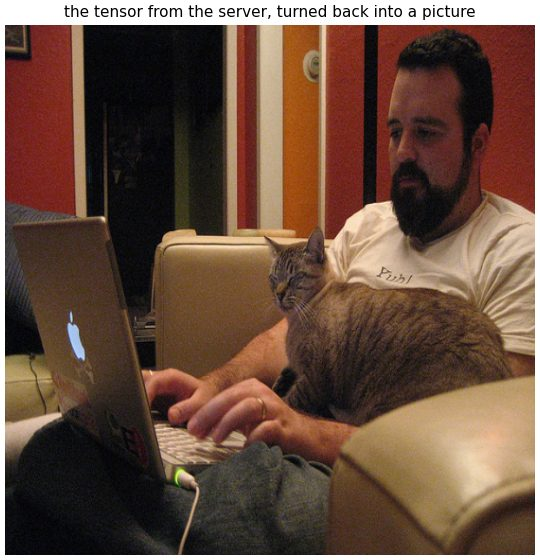

In [7]:
pre = client.preprocess("rf-detr", ho.photo("cat"))
x = pre.inputs["input"]
print("tensor:", x.shape, x.dtype, "min", round(float(x.min()), 3), "max", round(float(x.max()), 3))
print("meta:  ", pre.meta)

# Undo the colour scaling to get a normal picture back.
prep = info["details"]["preprocess"]
mean, std = np.array(prep["mean"]), np.array(prep["std"])
pixels = (x[0].transpose(1, 2, 0) * std + mean) * 255          # [3,H,W] -> [H,W,3], back to 0..255
seen = Image.fromarray(pixels.clip(0, 255).round().astype(np.uint8))

same = np.abs(np.asarray(seen, float) - np.asarray(Image.open(seen_png).convert("RGB"), float)).mean()
print(f"difference from the inspect picture of section 4: {same:.2f} gray levels (out of 255)")
ho.show(seen, title="the tensor from the server, turned back into a picture")

**What you see**

- The tensor has the same shape, `(1, 3, 560, 560)`, and the same range of values as in
  section 4.
- `meta` has six numbers: the photo's size (`orig_width`, `orig_height`), and how it was fitted:
  `scale_x` 0.875, `scale_y` 1.167, `pad_x` 0, `pad_y` 0 (no bars were added).
- The difference from the `inspect` picture is 0 gray levels (or very close): the server and the
  command-line program use the same code.
- To undo the colour scaling we use the formula backwards:
  `pixel = (value × std + mean) × 255`.

<details><summary><b>In detail</b></summary>

- `preprocess()` sends the photo as it is (no client-side resize), so you compare the server's
  tensor with yours for the same pixels.
- This is the best tool to compare the server with your training code: build the tensor with
  your training transform, then compare the two arrays. A difference above about 8 gray levels
  means a different preparation step. Notebook 05 does this for you with `visionserve check`.
- A **gray level** is one step on the 0 to 255 scale of a pixel. Measuring the difference in gray
  levels makes it easy to read, whatever the mean and std.
- For a text model (GroundingDINO) `preprocess()` also returns the token ids of the prompt.

More: [Inspect and verify a model, section 2](https://mtbui2010.github.io/visionserve/guides/inspect/#2-inspect-the-preprocessing).

</details>

## 8. From the model's square back to your photo

The model finds boxes in its own 560 × 560 square. Your code wants boxes on **your** photo. The
server moves every box back for you, with the numbers of `meta`. Here we do the same by hand, to
see how it works. The rule is:

```
tensor_x = photo_x × scale_x + pad_x        tensor_y = photo_y × scale_y + pad_y
```

The server's answer (boxes are [x, y, width, height] in the photo's pixels):
  laptop   0.91  [7.0, 172.4, 285.3, 241.1]
  cat      0.86  [309.8, 182.0, 304.1, 178.9]
  person   0.56  [169.2, 4.1, 469.5, 387.2]
  couch    0.55  [387.8, 316.2, 251.8, 159.6]

'laptop' on the photo:     x=7.0 y=172.4 w=285.3 h=241.1
'laptop' in the 560 square: x=7.0×0.875=6.2  y=172.4×1.167=201.1  w=249.7  h=281.3


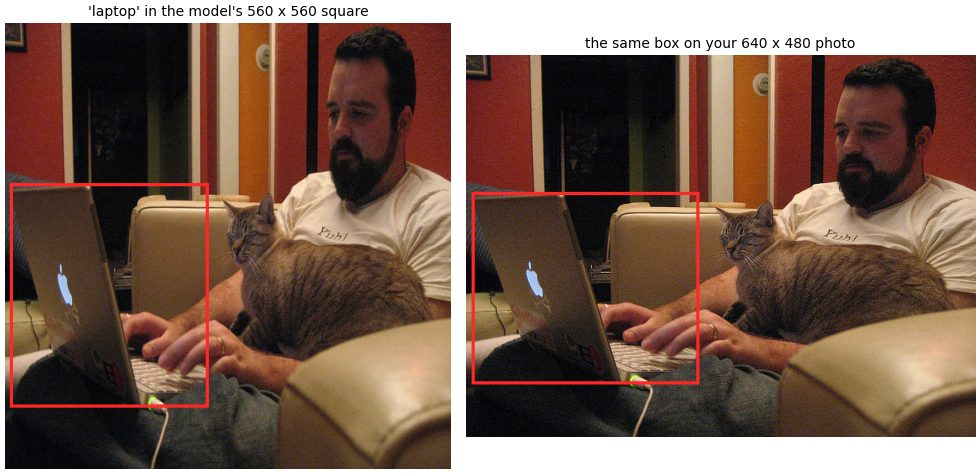

In [8]:
res = client.predict("rf-detr", ho.photo("cat"))
print("The server's answer (boxes are [x, y, width, height] in the photo's pixels):")
for d in res.detections:
    print(f"  {d.cls:<8} {d.conf:.2f}  {[round(v, 1) for v in d.bbox]}")

m = pre.meta
d = max(res.detections, key=lambda d: d.conf)                 # the most confident box
x0, y0, w, h = d.bbox
tx, ty = x0 * m["scale_x"] + m["pad_x"], y0 * m["scale_y"] + m["pad_y"]
tw, th = w * m["scale_x"], h * m["scale_y"]
print(f"\n'{d.cls}' on the photo:     x={x0:.1f} y={y0:.1f} w={w:.1f} h={h:.1f}")
print(f"'{d.cls}' in the 560 square: x={x0:.1f}×{m['scale_x']:.3f}={tx:.1f}  y={y0:.1f}×{m['scale_y']:.3f}={ty:.1f}  "
      f"w={tw:.1f}  h={th:.1f}")

photo_img = Image.open(ho.photo("cat")).convert("RGB")
square_img = seen.copy()
ImageDraw.Draw(photo_img).rectangle([x0, y0, x0 + w, y0 + h], outline=(255, 40, 40), width=4)
ImageDraw.Draw(square_img).rectangle([tx, ty, tx + tw, ty + th], outline=(255, 40, 40), width=4)
ho.show_side_by_side([square_img, photo_img],
                     titles=[f"'{d.cls}' in the model's 560 x 560 square", f"the same box on your 640 x 480 photo"])

**What you see**

- The list is the server's answer. Every `bbox` is `[x, y, width, height]` in the pixels of the
  photo you sent: `x, y` is the top-left corner.
- The two printed lines show the same box twice: once on your photo, once in the model's square
  (multiplied by `scale_x` and `scale_y`; no padding here).
- In the pictures, the red box covers the same object in both. On the left the object is
  stretched like the whole square; on the right it has its normal shape.

<details><summary><b>In detail</b></summary>

- The server applies the rule backwards: `photo_x = (tensor_x - pad_x) / scale_x`. With
  letterbox (next section) `pad_x` or `pad_y` is not 0, and forgetting it moves every box.
- The model itself returns boxes as `cx, cy, w, h` (centre, width, height) in 0 to 1 of the
  square. The server converts them to pixels and to `[x, y, w, h]` on your photo. Every model in
  VisionServe returns boxes this way, so your code never needs to know the model's square.

More: [From pixels to tensors, step 3](https://mtbui2010.github.io/visionserve/concepts/preprocessing/#step-3-map-the-answer-back-to-your-photo)
and [Inspect and verify a model, section 4](https://mtbui2010.github.io/visionserve/guides/inspect/#4-inspect-the-postprocessing).

</details>

## 9. Four ways to fit a photo into a square

Models were trained with different ways to fit a photo into their input. VisionServe has one
**mode** for each way, set in the manifest (`resize`). We look at four, on one wide photo:

| Mode | What it does | Example model |
|---|---|---|
| squash | stretch the whole photo to the square, aspect ratio not kept | `rf-detr` |
| letterbox | shrink to fit, keep the aspect ratio, fill the rest with bars | a scratch copy of `rf-detr` |
| centre crop | resize the short side, then cut out the middle | `efficientnet-b0` |
| long side | resize so the long side is 1024, keep the aspect ratio, no bars | `mobile-sam` |

No shipped RF-DETR uses letterbox, so for that panel we make one more scratch copy and use
`inspect --image` (it works without a server).

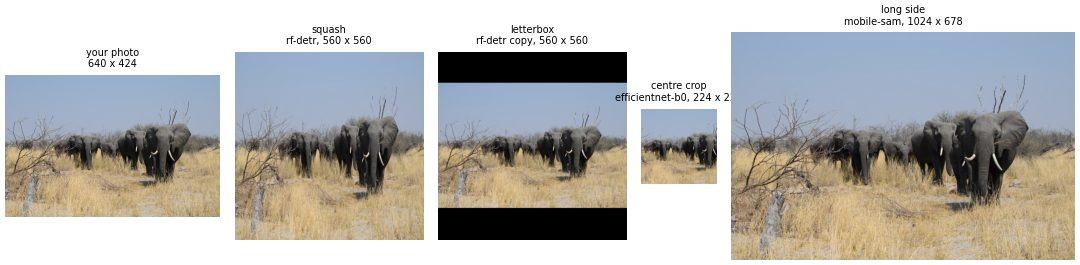

mode,model,tensor shape,how the photo was fitted (meta)
squash,rf-detr,"[1, 3, 560, 560]","scale_x 0.875, scale_y 1.321, pad_x 0, pad_y 0"
letterbox,rf-detr-letterbox,"[1, 3, 560, 560]","scale_x 0.875, scale_y 0.875, pad_x 0, pad_y 94"
centre crop,efficientnet-b0,"[1, 3, 224, 224]","scale_x 0.603, scale_y 0.604, pad_x -81, pad_y -16"
long side,mobile-sam,"[678, 1024, 3]",no meta: the model's graph fits the photo itself


In [9]:
P = ho.photo("elephant")
W, H = Image.open(P).size


def to_picture(t, prep):
    """Turn a model input tensor back into a picture (undo layout and colour scaling)."""
    a = t[0] if t.ndim == 4 else t                              # drop the batch axis
    if prep["layout"] == "NCHW":
        a = a.transpose(1, 2, 0)                                # [3,H,W] -> [H,W,3]
    if prep["mean"]:                                            # undo (v - mean) / std
        a = a * np.array(prep["std"]) + np.array(prep["mean"])
        if prep["rescale"]:
            a = a * 255
    return Image.fromarray(a.clip(0, 255).round().astype(np.uint8))


def fitted(meta):
    """meta as one short line."""
    if not meta:
        return "no meta: the model's graph fits the photo itself"
    return (f"scale_x {meta['scale_x']:.3f}, scale_y {meta['scale_y']:.3f}, "
            f"pad_x {meta['pad_x']:g}, pad_y {meta['pad_y']:g}")


panels, titles, rows = [P], [f"your photo\n{W} x {H}"], []
for name, mode in [("rf-detr", "squash"), ("efficientnet-b0", "centre crop"), ("mobile-sam", "long side")]:
    p = client.preprocess(name, P)
    t = next(iter(p.inputs.values()))
    pic = to_picture(t, cli_json("inspect", name)["details"]["preprocess"])
    panels.append(pic)
    titles.append(f"{mode}\n{name}, {pic.width} x {pic.height}")
    rows.append([mode, name, str(list(t.shape)), fitted(p.meta)])

# letterbox: a scratch copy of rf-detr with letterbox: true, seen with inspect --image
lb = reg / "rf-detr-letterbox"
lb.mkdir(parents=True, exist_ok=True)
for f in info["details"]["files"]:
    target, link = model_dir / f["path"], lb / f["path"]
    if not link.exists():
        try:
            link.symlink_to(target.resolve())
        except OSError:
            shutil.copy(target, link)
lb_text = re.sub(r"(?m)^name:.*$", "name: rf-detr-letterbox", text)
lb_text = re.sub(r"(?m)^(\s*letterbox:\s*)false", r"\g<1>true", lb_text)
(lb / "manifest.yaml").write_text(lb_text)
lb_png = WORK / "letterbox-input.png"
out = ho.run_cli("inspect", "rf-detr-letterbox", "--models", reg, "--image", P, "--image-out", lb_png, echo=False)
mapping = next(line for line in out.splitlines() if line.strip().startswith("Mapping"))
(sx, px), (sy, py) = re.findall(r"× ([\d.]+) \+ (-?[\d.]+)", mapping)
lb_meta = {"scale_x": float(sx), "scale_y": float(sy), "pad_x": float(px), "pad_y": float(py)}
panels.insert(2, lb_png)
titles.insert(2, "letterbox\nrf-detr copy, 560 x 560")
rows.insert(1, ["letterbox", "rf-detr-letterbox", "[1, 3, 560, 560]", fitted(lb_meta)])

ho.show_side_by_side(panels, titles=titles, max_width=1100)
ho.table(rows, ["mode", "model", "tensor shape", "how the photo was fitted (meta)"])

**What you see**

Five pictures of the same photo:

- **squash**: the whole elephant scene, stretched to a square. Nothing is lost, the shapes are
  changed. `scale_x` and `scale_y` differ.
- **letterbox**: the whole scene with its true shape, smaller, with bars above and below.
  One scale for both axes and a `pad_y` (the height of the top bar).
- **centre crop**: only the middle of the photo, 224 × 224. The left and right sides are cut off
  (and a thin strip at the top and bottom): the model never sees them. `pad_x` and `pad_y` are
  negative: the crop starts inside the photo.
- **long side**: the true shape, bigger (1024 wide), no bars. MobileSAM takes raw pixels
  (0 to 255) in NHWC order, and its graph does the rest itself, so there is no `meta`.

The table gives the numbers. With **squash**, `scale_x` and `scale_y` differ. With
**letterbox**, they are equal and `pad_y` is the height of the top bar.

None of these is "right" in general. The right one is the one **the model was trained with**.
A model fed the wrong mode still answers, but worse, and no error appears. Notebook 05 shows how
to catch this.

<details><summary><b>In detail</b></summary>

- The table in the guide lists every mode, including `keep_aspect` (Depth-Anything) and
  `top_left_pad` (SCRFD faces), and which models use them.
- Centre crop uses `crop_pct` for ImageNet classifiers: the short side is first resized a little
  larger (256 for a 224 crop), then the middle 224 × 224 is cut out.
- The mode comes from the manifest:
  ```yaml
  input:
    width: 560
    height: 560
    letterbox: false
  ```
  or, in newer manifests, a `preprocess:` block with `resize: squash`.

More: [From pixels to tensors, step 1](https://mtbui2010.github.io/visionserve/concepts/preprocessing/#step-1-make-the-image-the-size-the-model-expects)
and [Manifest format](https://mtbui2010.github.io/visionserve/reference/manifest/).

</details>

## 10. Clean up

We delete the scratch folder (the copied model file and the scratch registry). The real models
are not touched.

In [10]:
shutil.rmtree(WORK, ignore_errors=True)
print("deleted", WORK)

deleted work-03


## Recap

- `visionserve inspect NAME` prints a model card. The first line is the answer: PASS, WARN or FAIL.
- `[1, 3, 560, 560]` = 1 photo, 3 colours, 560 rows, 560 columns: 940,800 numbers.
- `inspect --image` and `client.preprocess()` show the exact picture and numbers the model gets.
- A bare `.onnx` file says its input and output shapes, but not how to prepare a photo. The
  manifest says that.
- A manifest whose size does not fit the model file is a `FAIL` with a clear fix.
- `meta` (scale and pad) moves boxes from the model's square back to your photo. The server does
  it for you: every `bbox` is in your photo's pixels.
- Squash, letterbox, centre crop and long side give different pictures. Only the one used in
  training is right.

## Next

- Notebook **04 · Your own checkpoint**: serve a model you trained yourself.
- Notebook **05 · Check against training**: let `visionserve check` compare the server with the
  training pipeline, and find a wrong mode for you.
- Read more: [See what a model takes and returns](https://mtbui2010.github.io/visionserve/guides/see-a-model/),
  [From pixels to tensors](https://mtbui2010.github.io/visionserve/concepts/preprocessing/),
  [Inspect and verify a model](https://mtbui2010.github.io/visionserve/guides/inspect/).